---

Digital Brain

---

In [1]:
# autoload
%load_ext autoreload
%autoreload 2

# import pgl commands
from pgl import pgl, pglExperiment, pglTask, pglParameter, pglKeyBuffer, pglEyeTrackingCalibrationTask, pglMessageAckTask, pglMessages, pglMovieDatabase

# import libraries
import json
from pathlib import Path
import numpy as np

# initialize pgl
pgl = pgl()
pgl.cleanUp()

================================ pglBase: init =================================
(pgl) mglMetal error log can be viewed in MacOS Console app by searching for PROCESS mglMetal or in a terminal with:
      log stream --level info --process mglMetal
(pgl) To search for something specifc, e.g. messages from mglMovie:
      log stream --predicate 'eventMessage CONTAINS "mglMovie"' --style syslog --level info
(pgl:checkOS) Python version: 3.12.13 | packaged by conda-forge | (main, Mar  5 2026, 17:06:14) [Clang 19.1.7 ]
(pgl:checkOS) Running on Mac mini (Mac14,3) with macOS version: 15.6.1
(pgl:checkOS) Apple M2 Cores: 8 (4 performance and 4 efficiency) Memory: 16 GB
(pgl:checkOS) GPU: Apple M2 (Built-In) 10 cores, Metal 3 support
(pgl:checkOS)   HP ZR2440w [Main Display]: 1920 x 1200 (WUXGA - Widescreen Ultra eXtended Graphics Array) (Unknown type) GammaTable size: 1024
(pgl:checkOS)   VIEWPixx3D: 1920 x 1080 (1080p FHD - Full High Definition) (Unknown type) GammaTable size: 1024
(pglBase) M

---

Display settings

---

In [ ]:
pgl.displaySettings()

---

Settings

---

In [ ]:
pgl.settings()

---

Memory only task

---

In [ ]:
class pglDescriptionTask(pglTask):
    
    ########################
    def __init__(self, pgl, subjectNum, dayNum, blockNum, descriptionLength=12, displayWidth=30):
        super().__init__(pgl)
        
        # initialize the key buffer
        self.keyBuffer = pglKeyBuffer(maxLineLength=40)
        
        # set task parameters, these will automatically be saved in the settings file
        self.settings.taskName = "Memory description task"
        
        # set seglens
        self.settings.seglen = [0.5, float('inf'), descriptionLength, 0.5]

        # fixed parameters, these will automatically be saved in the settings file
        self.settings.fixedParameters = {
            #'moviePath':'/Users/Shared/digital-assets/stimulus/digital/0008',
            #'moviePath':'/Users/justin/Desktop/testvideos',
            'moviePath':'/Users/Shared/digital',
            #'moviePath':'/Users/justin/Desktop/digital',
            'displayWidth': displayWidth,
            'subjectNum': subjectNum,
            'dayNum': dayNum,
            'blockNum': blockNum,
        }        
        p = self.settings.fixedParameters

        # response mappings for proper display
        self.data.responseMapping = {
            # Correct
            0: ("high confidence new", "#0072B2"),  # dark blue
            1: ("low confidence new",  "#8FC4E8"),  # light blue
            2: ("low confidence old",  "#F6BE73"),  # light orange
            3: ("high confidence old", "#D55E00"),  # dark orange-red
            4: ("remembered",          "#7B3294"),  # purple

            # Incorrect: same response category, muted / grayish version
            5: ("incorrect: high confidence new", "#6F8794"),
            6: ("incorrect: low confidence new",  "#B7C4CC"),
            7: ("incorrect: low confidence old",  "#C9B69C"),
            8: ("incorrect: high confidence old", "#9A7768"),
            9: ("incorrect: remembered",          "#8F7C96"),
        }
        
        # create the blockPath
        self.state.blockPath = Path(p['moviePath']) / f"1{subjectNum}{dayNum}{blockNum}"

        # load movie database
        self.mdb = pglMovieDatabase(self.state.blockPath)
        self.mdb.useManifest(filenameColumn="filename", indexColumn="trial_index", conditionColumn="condition")
        
        # get number of trials to run for 
        self.settings.nTrials=self.mdb.nStimuli
        
        # add parameters
        self.addParameter(pglParameter('movieNum',np.arange(self.mdb.nStimuli),randomize=False))
        self.addParameter(pglParameter('description',["description"]))
        
        # print
        print("=!"*40)
        print(f"{self.state.blockPath.name} subject={p['subjectNum']} day={p['dayNum']} block={p['blockNum']}")
        print("=!"*40)
        
        # print out the trials
        for iStimulus in range(self.mdb.nStimuli):
            m = self.mdb.stimuli[iStimulus]
            print(f"{iStimulus}: filename: {m.filename} condition: {m.condition}")
                    
                    
    ########################
    def startSegment(self, startTime):
        '''
        Start a segment.
        '''
        super().startSegment(startTime)
        
        if self.state.currentSegment == 0:
            self.e.flush = True
            # do not eat keys
            self.e.setEatAllKeys(False)
            # load the movie
            moviePath = self.mdb.stimuli[self.currentParams['movieNum']].filename
            condition = self.mdb.stimuli[self.currentParams['movieNum']].condition
            self.m = pgl.movie(filename=str(moviePath),displayWidth=self.settings.fixedParameters['displayWidth'])
            pglMessages.message(f"{self.state.currentTrial}: {self.m} moviePath: {moviePath} condition: {condition}")
        
        elif self.state.currentSegment == 1:
            self.state.gotResponse = False
            # play the movie
            self.m.play(displayWidth=self.settings.fixedParameters['displayWidth'])
            self.jumpSegment()

        elif self.state.currentSegment == 2:
            # description segment
            self.e.setEatAllKeys(True)
            self.keyBuffer.clear()
            self.state.keyBufferDirty=False
            self.state.elapsedTime = -1
            self.e.flush = False

        elif self.state.currentSegment == 3:
            self.e.flush = True
            self.e.setEatAllKeys(False)
            # save the description
            self.currentParams['description'] = self.keyBuffer.getText()
    ########################
    def updateScreen(self):
        if self.state.currentSegment == 0:
            pass
        elif self.state.currentSegment == 2:
            # calcluate elapsed time
            elapsedTime = round(self.settings.seglen[self.state.currentSegment]-(self.pgl.getSecs()-self.state.segmentStartTime),0)
            
            # decide if we need to draw (only if elapsed time has changed or keyBufferDirty)
            if elapsedTime != self.state.elapsedTime or self.state.keyBufferDirty:
                # update elapsed time
                self.state.elapsedTime = elapsedTime
                # draw text
                self.pgl.text(f"Describe: {elapsedTime:0.1f}", line="center")
            
                # draw the subject text
                text = self.keyBuffer.getWrappedText()
                for line in text.split('\n'):
                    self.pgl.text(line)
                self.state.keyBufferDirty = False
                
                # flush screen
                self.e.pgl.flush()
    
    ########################
    def handleEvents(self, events):
        for event in events:
            if event.eventType == 'keydown':
                self.keyBuffer.processEvent(event)
                self.state.keyBufferDirty = True

    ########################
    # handleSubjectResponse
    ########################    
    def handleSubjectResponse(self, response, updateTime):
        '''
        Handle the subject response. Returns the value 0-4 if correct see responseMapping above for explanation
        For incorrect answers returns 5-9
        '''
        # already received a response
        if self.state.gotResponse: return None
        # mark that we got a response
        self.state.gotResponse = True
        
        condition = self.mdb.stimuli[self.currentParams['movieNum']].condition
        if condition.lower().startswith("new"):
            # if not a new response then make it incorrect
            if response not in {0,1}: response += 5
        else:
            # if a new response then make it incorrect
            if response in {0,1}: response += 5
               
        # check if response is correct 
        return response
    
    ########################
    # handleSubjectResponse
    ########################    
    def end(self):
        '''
        end of task
        '''
        super().end()
        # make sure flush is set back to normal
        self.e.flush = True
        # do not eat keys
        self.e.setEatAllKeys(False)


<div style="background-color:#e6f4ea; padding:15px; border-left:6px solid #2e7d32; color:#1b4332; font-size:18px;">
<b>Choose parameters for each block</b>
</div>

In [ ]:
# init current choice if it is ot already
from pgl import pglChooseBlock
if "currentRun" not in locals(): currentRun = pglChooseBlock(subjectMax=4, dayMax=2, blockMax=4)
currentRun = pgl.traitsDialog(currentRun)
currentRun.print()

---

Initialize task

---

In [ ]:
# make session and run name
sessionName = f"day{currentRun.dayNum:01d}"
runName = f"run{currentRun.blockNum:01d}"
subjectID = currentRun.subjectID

# calibration settings
nCalibrationPoints = currentRun.nCalibrationPoints[0]
calibrationWidth = currentRun.calibrationSize[0]
calibrationHeight = currentRun.calibrationSize[1]

# other settings
descriptionLength = currentRun.descriptionLength
displayWidth = currentRun.displayWidth

# Set up experiment
e = pglExperiment(pgl, subjectID=subjectID, experimentName="Digital Brain Memory pilot", sessionName=sessionName, runName=runName)

# First run a calibration
messageAckTask = pglMessageAckTask(pgl, "Press 1 to start eye calibration")
messageAckTask.settings.phaseNum=0
e.addTask(messageAckTask)
calibrationTask = pglEyeTrackingCalibrationTask(pgl, nCalibrationPoints=nCalibrationPoints, calibrationWidth=calibrationWidth, calibrationHeight=calibrationHeight)
calibrationTask.settings.phaseNum=1
e.addTask(calibrationTask)

# description task
descriptionTask = pglDescriptionTask(pgl, subjectNum=currentRun.subjectNum, dayNum=currentRun.dayNum, blockNum=currentRun.blockNum, descriptionLength=descriptionLength, displayWidth=displayWidth)
descriptionTask.settings.phaseNum = 2
e.addTask(descriptionTask)

# calibration
messageAckTask = pglMessageAckTask(pgl, "Press any response key to start eye calibration")
messageAckTask.settings.phaseNum = 3
e.addTask(messageAckTask)
calibrationTask = pglEyeTrackingCalibrationTask(pgl, nCalibrationPoints=nCalibrationPoints, calibrationWidth=calibrationWidth, calibrationHeight=calibrationHeight)
calibrationTask.settings.phaseNum = 4
e.addTask(calibrationTask)

---

Run task

---

In [ ]:
# initialize scree
e.initScreen()

# and run the experiment
e.run()

# display results
e.display()

In [ ]:
print(e.state.phaseNum)

---

Movie database

---

In [ ]:
from pgl import pglMovieDatabase
mdb = pglMovieDatabase('/Users/Shared/digital-assets/stimulus/digital/0008')

In [ ]:
mdb.display(stimulusNum=5)
#pgl.traitsDialog(mdb)

In [ ]:
pgl.traitsDialog(mdb)

In [ ]:
mdb.stimuli[0].filename

In [ ]:
pgl.getPGLDir()

In [ ]:
e.initScreen()
e.run()
e.display()

---

Eye Tracker Test

---

In [2]:
# Set up experiment
e = pglExperiment(pgl, experimentName="Eye calibration")

for iCalibration in range(5):
    # tell the subject what will happen
    messageAckTask = pglMessageAckTask(pgl, "Press 1 to do eye calibration")
    messageAckTask.settings.phaseNum=iCalibration*2
    e.addTask(messageAckTask)

    # calibration task
    calibrationTask = pglEyeTrackingCalibrationTask(pgl, nCalibrationPoints=17, calibrationWidth=15, calibrationHeight=15)
    calibrationTask.settings.phaseNum=iCalibration*2+1
    e.addTask(calibrationTask)


In [3]:
e.initScreen()
e.run()

(pglBase:removeOrphanedSockets) No orphaned sockets found in /Users/justin/Library/Containers/gru.mglMetal/Data
(pgl:_resolution:getResolution) Display 1/2: 1920x1080 60Hz 32bits
(pgl:_resolution:setBestMode) Setting display 1 to 1920x1080 60Hz 32 bits
(pglExperiment:initScreen) Changing screen resolution to: 1920 x 1200 60Hz 32bits from: 1920 x 1080 60Hz 32bits
================================= pglBase:open =================================
(pgl:_resolution:getResolution) Display 1/2: 1920x1080 60Hz 32bits
(pgl:_resolution:getResolution) Display 0/2: 1920x1200 60Hz 32bits
(pgl->pglBase:open) Starting mglMetal application: /Users/justin/proj/pgl/metal/mglMetal.app
(pgl->pglBase:open) Using socket with address: /Users/justin/Library/Containers/gru.mglMetal/Data/pglMetal.socket.20260827_181528.44zYKreIIr
(pgl:_pglComm) .Connected to: /Users/justin/Library/Containers/gru.mglMetal/Data/pglMetal.socket.20260827_181528.44zYKreIIr
(pgl:_resolution:getResolution) Display 1/2: 1920x1080 60Hz 32

1495 thread_policy_set failed: 4.
1466 thread_policy_set failed: 4.
1495 thread_policy_set failed: 4.
1495 thread_policy_set failed: 4.
1495 thread_policy_set failed: 4.


(pglEyelink:openEDF) Data file opened: 20260827.edf
(pglEyelink:__init__) (pglEyelink) Using pgl display for Eyelink calibration and validation.
(pglEyelink:start) Eye tracking started.
(pglExperiment:calibrateEyeTracker) Press space to calibrate eye tracker. return to skip.
(pglEventListener) Eating 2 keys: ['return', 'space']
(pglEventListener) Eating 13 keys: ['1', '2', '3', '4', '5', '<keycode:83>', '<keycode:84>', '<keycode:85>', '<keycode:86>', '<keycode:87>', '`', 'escape', 'space']
################################################################################
(pglEyelink:calibrate) Starting calibration routine
             Enter: Show camera image
             C: (C)alibrate V: (V)alidate
             0 or Q: (Q)uit calibration
################################################################################
(pglEventListener) Eating 6 keys: ['0', '<keycode:82>', 'c', 'q', 'return', 'v']
(pglEventListener) Eating 13 keys: ['1', '2', '3', '4', '5', '<keycode:83>', '<keycode:84>

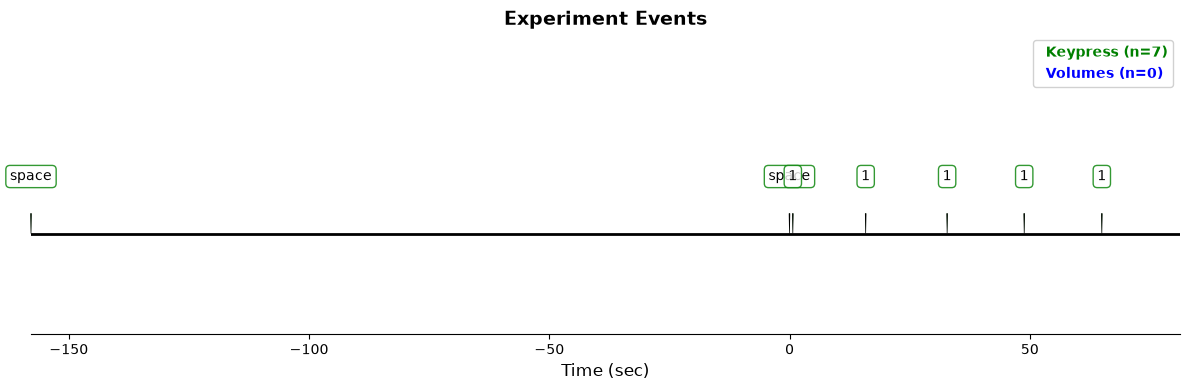

(pglTaskData:display) Insufficient trial events found to display.
(pglTaskData:display) Insufficient trial events found to display.
(pglTaskData:display) Insufficient trial events found to display.
(pglTaskData:display) Insufficient trial events found to display.
(pglTaskData:display) Insufficient trial events found to display.


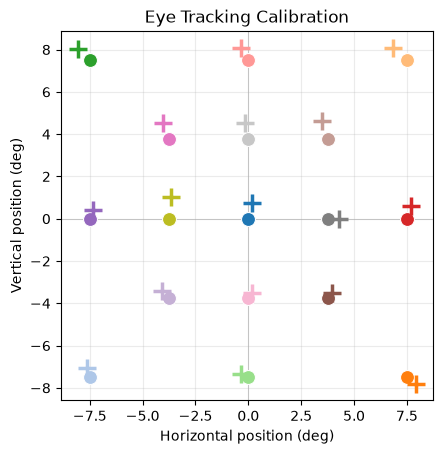

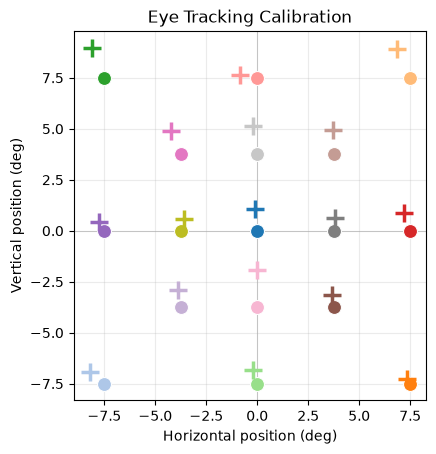

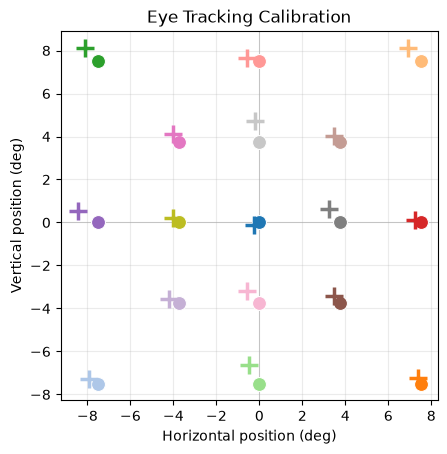

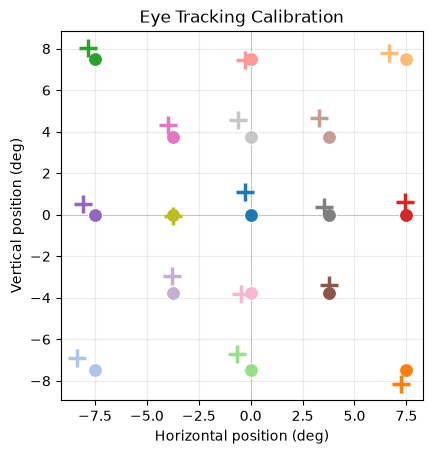

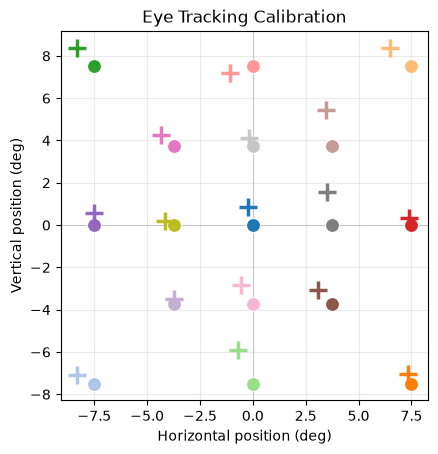

In [4]:
e.display()

In [ ]:

import inspect
import pylink
print(inspect.getsource(pylink.EyeLinkCustomDisplay.draw_cross_hair))
print(inspect.getsource(pylink.EyeLinkCustomDisplay.draw_line))
print(inspect.getmembers(
    pylink.EyeLinkCustomDisplay,
    predicate=inspect.isfunction
))

import pylink

print("PyLink location:", pylink.__file__)
print("PyLink version:", getattr(pylink, "__version__", "unknown"))

import pylink.__version__ as v

print(v.__file__)
print(dir(v))
print(v.__version__)
print(inspect.getsource(pglEyeTrackingCalibrationTask))

Todo: 
save do not print movie output
make settings work outside of pgl main library
stable setting does not stick
display metal version in pglBase init
